## 0. 환경설정

In [ ]:
!pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 59.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

## 1. 데이터 로드

In [ ]:
courses = pd.read_csv("Coursera_courses.csv")

In [ ]:
reviews = pd.read_csv("Coursera_reviews.csv")

In [ ]:
print(f"강좌 테이블: {courses.shape[0]:,}행 x {courses.shape[1]}열")
print(f"리뷰 테이블: {reviews.shape[0]:,}행 x {reviews.shape[1]}열")
courses.head()

강좌 테이블: 623행 x 4열
리뷰 테이블: 1,454,711행 x 5열


,name,institution,course_url,course_id
0,Machine Learning,Stanford University,https://www.coursera.org/learn/machine-learning,machine-learning
1,Indigenous Canada,University of Alberta,https://www.coursera.org/learn/indigenous-canada,indigenous-canada
2,The Science of Well-Being,Yale University,https://www.coursera.org/learn/the-science-of-...,the-science-of-well-being
3,Technical Support Fundamentals,Google,https://www.coursera.org/learn/technical-suppo...,technical-support-fundamentals
4,Become a CBRS Certified Professional Installer...,Google - Spectrum Sharing,https://www.coursera.org/learn/google-cbrs-cpi...,google-cbrs-cpi-training


In [ ]:
reviews.head()

,reviews,reviewers,date_reviews,rating,course_id
0,"Pretty dry, but I was able to pass with just t...",By Robert S,"Feb 12, 2020",4,google-cbrs-cpi-training
1,would be a better experience if the video and ...,By Gabriel E R,"Sep 28, 2020",4,google-cbrs-cpi-training
2,Information was perfect! The program itself wa...,By Jacob D,"Apr 08, 2020",4,google-cbrs-cpi-training
3,A few grammatical mistakes on test made me do ...,By Dale B,"Feb 24, 2020",4,google-cbrs-cpi-training
4,Excellent course and the training provided was...,By Sean G,"Jun 18, 2020",4,google-cbrs-cpi-training


In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1454711 entries, 0 to 1454710
Data columns (total 5 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   reviews       1454558 non-null  object
 1   reviewers     1454711 non-null  object
 2   date_reviews  1454711 non-null  object
 3   rating        1454711 non-null  int64 
 4   course_id     1454711 non-null  object
dtypes: int64(1), object(4)
memory usage: 55.5+ MB


### 1-1. 별점 분포

In [ ]:
rating_counts = reviews["rating"].value_counts().sort_index()
rating_ratio = rating_counts / len(reviews) * 100

rating_dist = pd.DataFrame({"수": rating_counts, "비율(%)": rating_ratio.round(1)})
rating_dist

,수,비율(%)
rating,,
1,17354,1.2
2,16188,1.1
3,48303,3.3
4,226702,15.6
5,1146164,78.8


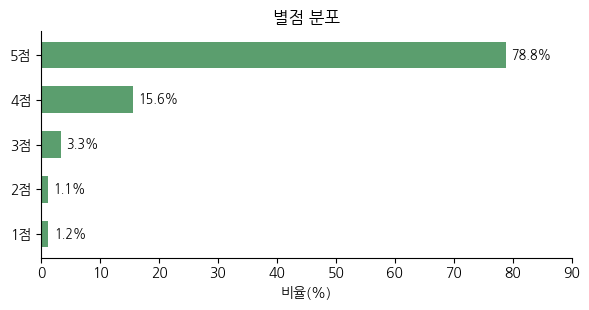

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.barh(rating_dist.index, rating_dist["비율(%)"], color="#5B9E6E", height=0.6)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set_yticks(range(1, 6), [f"{i}점" for i in range(1, 6)])
ax.set_xlim(0, 90)
ax.set_xlabel("비율(%)")
ax.set_title("별점 분포")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

### 1-2. 결측 & 중복값

In [ ]:
reviews.isnull().sum()

,0
reviews,153
reviewers,0
date_reviews,0
rating,0
course_id,0


In [ ]:
# (A) 텍스트만 동일 — 짧고 흔한 표현("good") 으로 인한 자연 발생
text_dup = reviews["reviews"].duplicated().sum()

# (B) 리뷰어 + 텍스트 + 강좌가 모두 동일 = 동일인의 동일 리뷰
true_dup = reviews.duplicated(subset=["reviews", "reviewers", "course_id"]).sum()

print(f"(A) 텍스트만 동일        : {text_dup:,}건 ({text_dup / len(reviews) * 100:.1f}%)")
print(f"(B) 리뷰어+텍스트+강좌 동일: {true_dup:,}건 ({true_dup / len(reviews) * 100:.1f}%)")

(A) 텍스트만 동일        : 996,434건 (68.5%)
(B) 리뷰어+텍스트+강좌 동일: 934,783건 (64.3%)


### 1-3. 두 테이블 정합성

In [ ]:
review_ids = set(reviews["course_id"])
course_ids = set(courses["course_id"])

print(f"리뷰엔 있으나 강좌 정보가 없는 course_id: {len(review_ids - course_ids)}개")
print(f"강좌 정보는 있으나 리뷰가 0건인 course_id: {len(course_ids - review_ids)}개")
print(f"\n리뷰 분석 대상 강좌 수: {len(review_ids):,}개")

리뷰엔 있으나 강좌 정보가 없는 course_id: 0개
강좌 정보는 있으나 리뷰가 0건인 course_id: 19개

리뷰 분석 대상 강좌 수: 604개


### 1-4. 가장 흔한 리뷰 키워드

In [ ]:
top_reviews = reviews["reviews"].value_counts().head(10)

In [ ]:
print(top_reviews)

reviews
good                8827
Good                5445
Excellent           3678
Great course!       2446
great               2151
nice                2113
Excellent course    2063
very good           2051
Great course        2022
excellent           2018
Name: count, dtype: int64


In [ ]:
good = reviews[reviews["reviews"] == "good"]
print(f"\n'good' 리뷰: 총 {len(good):,}건 / 서로 다른 리뷰어 {good["reviewers"].nunique():,}명")


'good' 리뷰: 총 8,827건 / 서로 다른 리뷰어 2,682명


In [ ]:
review_ids = set(reviews['course_id'].unique())
course_ids = set(courses['course_id'].unique())

# 리뷰엔 있는데 강좌명 목록엔 없는 id  = A
no_info = review_ids - course_ids
# 강좌명 목록에 있지만 리뷰가 0건인 강좌 = B
no_review = course_ids - review_ids

print(f"A course_id: {len(no_info)}개")
print(f"B: {len(no_review)}개")
print(f"\n리뷰 분석 대상 강좌 수: {len(review_ids):,}개")

A course_id: 0개
B: 19개

리뷰 분석 대상 강좌 수: 604개


## 2. 지표 확인

In [ ]:
df = reviews.merge(
    courses[["course_id", "name", "institution"]],
    on = "course_id",
    how = "left"
)

In [ ]:
# 부정적 리뷰 여부 (1~3점)

df["is_negative"] = df["rating"] <= 3

# 날짜 타입 변경하기
df["date"] = pd.to_datetime(df["date_reviews"], format = "%b %d, %Y", errors="coerce")
df["year"] = df["date"].dt.year

In [ ]:
# 리뷰 길이

df["review_len"] = df["reviews"].str.len()

### 2-1. 강좌별 부정 리뷰 비율 집계

In [ ]:
course_stats = df.groupby("course_id").agg(
    name = ("name", "first"),
    institution = ("institution", "first"),
    review_count = ("rating", "size"),
    neg_ratio = ("is_negative", "mean")
).reset_index()

course_stats["neg_ratio"] = (course_stats["neg_ratio"] * 100).round(1)

In [ ]:
course_stats.shape

(604, 5)

In [ ]:
# 부정 비율 높은 순으로만 정렬
course_stats.sort_values("neg_ratio", ascending=False).head(10)

,course_id,name,institution,review_count,neg_ratio
495,social-economic-networks,Social and Economic Networks: Models and Anal...,Stanford University,6,100.0
172,epigenetics,Epigenetic Control of Gene Expression,The University of Melbourne,6,100.0
166,entrepreneurship-strategy,Entrepreneurship Strategy: From Ideation to Exit,HEC Paris,6,100.0
112,curanderismo-plants,Curanderismo: Traditional Healing Using Plants,University of New Mexico,6,100.0
26,attention-models-in-nlp,Natural Language Processing with Attention Models,DeepLearning.AI,49,51.0
3,accounting-data-analytics-python,Accounting Data Analytics with Python,University of Illinois at Urbana-Champaign,24,50.0
324,introduction-trading-machine-learning-gcp,"Introduction to Trading, Machine Learning & GCP",New York Institute of Finance,368,46.2
328,japanese-1,Japanese for beginners 1,Saint Petersburg State University,78,46.2
406,pca-machine-learning,Mathematics for Machine Learning: PCA,Imperial College London,1462,44.4
585,wharton-introduction-spreadsheets-models,Introduction to Spreadsheets and Models,University of Pennsylvania,1674,41.9


### 2-2. 리뷰 수 기준선 잡기

- 기준선이 필요한 이유 : 리뷰가 너무 적은 강좌는 비율이 과장되므로,
리뷰가 일정 수 이상인 강좌만 분석 대상으로 삼는 것이 정확할 것

In [ ]:
# 강좌별 리뷰 수가 어떻게 분포하는지
course_stats["review_count"].describe()

,review_count
count,604.000000
mean,2408.461921
std,4599.422887
min,3.000000
25%,374.250000
50%,1071.500000
75%,2408.250000
max,45218.000000


In [ ]:
# 리뷰 100개 이상인 강좌만 남기고, 부정 비율 높은 순 정렬
MIN_REVIEWS = 100

risk_courses = course_stats[course_stats["review_count"] >= MIN_REVIEWS] \
    .sort_values("neg_ratio", ascending=False)

print(f"기준 통과 강좌: {len(risk_courses)}개 (리뷰 {MIN_REVIEWS}개 이상)")
risk_courses.head(15)

기준 통과 강좌: 569개 (리뷰 100개 이상)


,course_id,name,institution,review_count,neg_ratio
324,introduction-trading-machine-learning-gcp,"Introduction to Trading, Machine Learning & GCP",New York Institute of Finance,368,46.2
406,pca-machine-learning,Mathematics for Machine Learning: PCA,Imperial College London,1462,44.4
585,wharton-introduction-spreadsheets-models,Introduction to Spreadsheets and Models,University of Pennsylvania,1674,41.9
40,big-data-essentials,"Big Data Essentials: HDFS, MapReduce and Spark...",Yandex,290,40.0
281,instructional-design-foundations-applications,Instructional Design Foundations and Applications,University of Illinois at Urbana-Champaign,189,39.7
465,quantum-computing-algorithms,The Introduction to Quantum Computing,Saint Petersburg State University,126,38.1
15,analytics-excel,Mastering Data Analysis in Excel,Duke University,2277,32.8
231,geopolitics-europe,Geopolitics of Europe,Sciences Po,235,32.3
489,sequence-models-in-nlp,Natural Language Processing with Sequence Models,DeepLearning.AI,186,30.6
31,aws-fundamentals-addressing-security-risk,AWS Fundamentals: Addressing Security Risk,Amazon Web Services,756,30.6


### 2-3. 강좌별 부정 리뷰 개수 집계

In [ ]:
# 부정 비율 → 부정 리뷰 '개수'로도 환산
risk_courses = risk_courses.copy()
risk_courses["neg_count"] = (risk_courses["review_count"] * risk_courses["neg_ratio"] / 100).round().astype(int)

# 부정 '개수'가 많은 순 = 가장 많은 사람이 불만인 강좌
risk_courses.sort_values('neg_count', ascending=False)[
    ["name", "institution", "review_count", "neg_ratio", "neg_count"]
].head(10)

,name,institution,review_count,neg_ratio,neg_count
450,Introduction to Data Science in Python,University of Michigan,14292,17.6,2515
466,R Programming,Johns Hopkins University,11832,20.0,2366
446,Programming for Everybody (Getting Started wit...,University of Michigan,45218,5.1,2306
400,Tools for Data Science,IBM,8241,26.9,2217
122,The Data Scientist’s Toolbox,Johns Hopkins University,17598,11.5,2024
595,What is Data Science?,IBM,21087,7.3,1539
453,Python for Data Science and AI,IBM,7989,17.0,1358
532,Technical Support Fundamentals,Google,35319,3.3,1166
457,Using Python to Access Web Data,University of Michigan,19011,5.6,1065
84,The Bits and Bytes of Computer Networking,Google,14176,7.5,1063


### 2-4. 비율 + 절댓값 합쳐서 보기

In [ ]:
# 두 축의 '높음/낮음'을 가르는 기준 = 각각의 중앙값
ratio_line = risk_courses["neg_ratio"].median()
count_line = risk_courses["neg_count"].median()

print(f"부정 비율 경계선 (중앙값): {ratio_line:.1f}%")
print(f"부정 절대량 경계선 (중앙값): {count_line:.0f}건")

부정 비율 경계선 (중앙값): 4.5%
부정 절대량 경계선 (중앙값): 50건


In [ ]:
def classify(row):
    high_ratio = row['neg_ratio'] >= ratio_line
    high_count = row['neg_count'] >= count_line
    if high_ratio and high_count:
        return "최우선 개선군"
    elif high_ratio and not high_count:
        return "비율 위험"
    elif not high_ratio and high_count:
        return "규모 위험"
    else:
        return "양호"

risk_courses["quadrant"] = risk_courses.apply(classify, axis=1)

# 각 그룹에 몇 개씩 들어갔는지
print(risk_courses["quadrant"].value_counts())

quadrant
최우선 개선군    192
양호         189
비율 위험       95
규모 위험       93
Name: count, dtype: int64


In [ ]:
# 최우선 개선군 그룹
top_action = risk_courses[risk_courses["quadrant"] == "최우선 개선군"] \
    .sort_values(["neg_ratio", "neg_count"], ascending=False)

top_action[["name", "institution", "review_count", "neg_ratio", "neg_count"]].head(15)

,name,institution,review_count,neg_ratio,neg_count
324,"Introduction to Trading, Machine Learning & GCP",New York Institute of Finance,368,46.2,170
406,Mathematics for Machine Learning: PCA,Imperial College London,1462,44.4,649
585,Introduction to Spreadsheets and Models,University of Pennsylvania,1674,41.9,701
40,"Big Data Essentials: HDFS, MapReduce and Spark...",Yandex,290,40.0,116
281,Instructional Design Foundations and Applications,University of Illinois at Urbana-Champaign,189,39.7,75
15,Mastering Data Analysis in Excel,Duke University,2277,32.8,747
231,Geopolitics of Europe,Sciences Po,235,32.3,76
31,AWS Fundamentals: Addressing Security Risk,Amazon Web Services,756,30.6,231
489,Natural Language Processing with Sequence Models,DeepLearning.AI,186,30.6,57
251,Building Scalable Java Microservices with Spri...,Google Cloud,473,28.3,134


## 3. 감성 분석

- 감성 분석을 위한 VADER 설치

In [ ]:
!pip install vaderSentiment -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.3 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [ ]:
text_df = df.dropna(subset=["reviews"]).copy()
text_df = text_df[text_df["review_len"] >= 20] # 너무 짧은 리뷰는 제외 : 20자 이상 리뷰로 보기

In [ ]:
print(f"총 리뷰 수: {len(df):,}건")
print(f"분석 대상: {len(text_df):,}건 ({len(text_df)/len(df)*100:.1f}%)")

총 리뷰 수: 1,454,711건
분석 대상: 1,241,849건 (85.4%)


- 샘플 테스트

In [ ]:
# 1만 건 샘플
sample = text_df.sample(10000, random_state=42).copy()

# 각 리뷰에 compound 점수 매기기
sample["sentiment"] = sample["reviews"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

# 결과 확인: 별점이랑 감성 점수가 대체로 같은 방향인지
sample.groupby("rating")["sentiment"].mean().round(3)

,sentiment
rating,
1,-0.158
2,0.151
3,0.252
4,0.488
5,0.607


In [ ]:
import time
start = time.time()

# 124만 건 전체에 compound 점수 매기기
text_df["sentiment"] = text_df["reviews"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

text_df["sentiment"].describe()

,sentiment
count,1.241849e+06
mean,5.565246e-01
std,3.738518e-01
min,-9.971000e-01
25%,4.199000e-01
50%,6.696000e-01
75%,8.462000e-01
max,9.999000e-01


In [ ]:
print(f"점수 매겨진 리뷰: {len(text_df):,}건")

점수 매겨진 리뷰: 1,241,849건


### 3-1. 숨은 불만 리뷰 추출 및 정의

In [ ]:
# 고평점(4~5점)이지만 텍스트 감성은 부정적인 리뷰 = '숨은 불만'
hidden = text_df[(text_df["rating"] >= 4) & (text_df["sentiment"] < 0)].copy()

print(f"고평점(4~5) 리뷰: {(text_df["rating"] >= 4).sum():,}건")
print(f"그중 텍스트가 부정적인 '숨은 불만': {len(hidden):,}건 "
      f"({len(hidden)/(text_df["rating"] >= 4).sum()*100:.1f}%)")

# 실제로 어떤 리뷰인지 5개 샘플
hidden.sort_values("sentiment")[["rating", "sentiment", "reviews"]].head(5)

고평점(4~5) 리뷰: 1,165,854건
그중 텍스트가 부정적인 '숨은 불만': 38,065건 (3.3%)


,rating,sentiment,reviews
556630,4,-0.9817,Considering the amount of information I think ...
556655,4,-0.9817,Considering the amount of information I think ...
556680,4,-0.9817,Considering the amount of information I think ...
565442,5,-0.9796,I am now able to Identify the major types of ...
565492,5,-0.9796,I am now able to Identify the major types of ...


### 3-2. 구간 설정

In [ ]:
# 감성 점수 구간을 나눠서 각 구간 리뷰를 직접 확인

print("강한 부정적 감성 (-1.0 ~ -0.6)")
display(hidden[hidden['sentiment'] < -0.6]
        .sample(5, random_state=1)[['rating', 'sentiment', 'reviews']])

강한 부정적 감성 (-1.0 ~ -0.6)


,rating,sentiment,reviews
354355,4,-0.8020,"An informative course, which shows some of the..."
1150550,5,-0.6808,De inicio me salio un poco difícil empezar el ...
979485,4,-0.8334,"Pretty good, lots of good practice but it gets..."
1019143,4,-0.7906,"El curso es muy completo, y enseña de forma si..."
1227585,5,-0.6351,Un curso que sin duda complementa mis conocimi...


In [ ]:
print("중간 부정적 감성 (-0.6 ~ -0.3)")
display(hidden[(hidden['sentiment'] >= -0.6) & (hidden['sentiment'] < -0.3)]
        .sample(5, random_state=1)[['rating', 'sentiment', 'reviews']])

중간 부정적 감성 (-0.6 ~ -0.3)


,rating,sentiment,reviews
150087,4,-0.4782,This course could be week one of a larger cour...
1337428,5,-0.3595,Excelente! no solo el diseño y estructuracion ...
1417798,4,-0.4753,Would have given a 5-star rating but I have to...
1310023,5,-0.4576,This course is good.But because of fucking ann...
629413,4,-0.3384,Extremely hard for someone like me who is tryi...


In [ ]:
print("약한 부정적 감성 (-0.3 ~ 0)")
display(hidden[hidden['sentiment'] >= -0.3]
        .sample(5, random_state=1)[['rating', 'sentiment', 'reviews']])

약한 부정적 감성 (-0.3 ~ 0)


,rating,sentiment,reviews
573996,4,-0.1406,"The course is awesome, but I had different exp..."
1197339,5,-0.2960,"No hay mejor curso en el que haya estado, en c..."
1372917,5,-0.1027,This course cleared many of my doubts about ML...
632676,5,-0.2960,Es excelente el curso. Me está ayudando a comp...
1150589,5,-0.2960,Es un curso excelente. La explicación de los t...


### 3-3. 언어 식별

In [ ]:
!pip install langdetect -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 41.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0

def safe_detect(text):
    try:
        return detect(text)
    except:
        return "unknown"

# 숨은 불만 3.8만 건에만 적용
hidden["lang"] = hidden["reviews"].apply(safe_detect)

print(hidden["lang"].value_counts().head(10))

lang
en    24364
es    11617
pt     1292
fr      449
de      115
no       36
it       35
af       32
ru       30
da       21
Name: count, dtype: int64


In [ ]:
# 영어 + 확실한 부정 리뷰만
hidden_clean = hidden[(hidden["lang"] == "en") & (hidden["sentiment"] < -0.3)].copy()

print(f"검증 전: {len(hidden):,}건")
print(f"  → 영어만: {(hidden['lang']=='en').sum():,}건")
print(f"  → 영어 + 확실한 부정: {len(hidden_clean):,}건")

# 강좌별로 숨은 불만이 몇 건이나 있는지
hidden_by_course = hidden_clean.groupby(["course_id","name","institution"]) \
    .size().reset_index(name="hidden_count") \
    .sort_values("hidden_count", ascending=False)

hidden_by_course.head(15)

검증 전: 38,065건
  → 영어만: 24,364건
  → 영어 + 확실한 부정: 12,028건


,course_id,name,institution,hidden_count
248,machine-learning,Machine Learning,Stanford University,356
338,python-data-analysis,Introduction to Data Science in Python,University of Michigan,345
283,neural-networks-deep-learning,Neural Networks and Deep Learning,DeepLearning.AI,341
246,learning-how-to-learn,Learning How to Learn: Powerful mental tools t...,University of California San Diego,312
334,python,Programming for Everybody (Getting Started wit...,University of Michigan,304
251,machine-learning-projects,Structuring Machine Learning Projects,DeepLearning.AI,286
40,cancer,Introduction to the Biology of Cancer,Johns Hopkins University,259
394,technical-support-fundamentals,Technical Support Fundamentals,Google,258
66,convolutional-neural-networks,Convolutional Neural Networks,DeepLearning.AI,235
345,python-network-data,Using Python to Access Web Data,University of Michigan,210


## 4. VOC 키워드 분석

In [ ]:
from collections import Counter
import re

# 숨은 불만 리뷰를 다 합쳐서 단어 쪼개기
text = ' '.join(hidden_clean["reviews"].astype(str)).lower()
words = re.findall(r'\b[a-z]+\b', text)   # 영어 단어만

# 가장 많이 나온 단어 20개
Counter(words).most_common(20)

[('the', 21580),
 ('to', 12383),
 ('and', 10502),
 ('i', 10230),
 ('a', 8607),
 ('of', 8543),
 ('course', 7852),
 ('is', 6902),
 ('in', 6615),
 ('it', 6184),
 ('this', 5075),
 ('but', 4715),
 ('for', 4330),
 ('not', 4168),
 ('that', 4137),
 ('was', 4066),
 ('are', 3198),
 ('very', 3178),
 ('you', 3027),
 ('with', 2842)]

In [ ]:
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

# 표준 영어 불용어 + 너무 흔해 의미 없는 단어
stop = set(stopwords.words('english'))
stop |= {'course', 'courses', 'class', 'one', 'would', 'also', 'get', 'really',
         'much', 'even', 'lot', 'well', 'good', 'great', 'like'}  # 추가 노이즈

# 불용어 빼고, 2글자 이하도 제거
words_clean = [w for w in words if w not in stop and len(w) > 2]

Counter(words_clean).most_common(30)

[('difficult', 1745),
 ('problems', 1176),
 ('learning', 1172),
 ('understand', 1147),
 ('time', 1066),
 ('assignments', 1050),
 ('problem', 1034),
 ('assignment', 854),
 ('many', 838),
 ('bit', 806),
 ('learn', 800),
 ('wrong', 755),
 ('programming', 741),
 ('videos', 709),
 ('learned', 701),
 ('content', 700),
 ('think', 672),
 ('work', 653),
 ('way', 651),
 ('could', 634),
 ('week', 628),
 ('little', 607),
 ('python', 566),
 ('informative', 549),
 ('know', 549),
 ('need', 549),
 ('questions', 541),
 ('knowledge', 537),
 ('material', 521),
 ('people', 509)]

In [ ]:
# 키워드 빈도를 보고 정의한 불만 유형 → 대표 단어들
voc_types = {
    '난이도':       ['difficult', 'hard', 'understand', 'confusing', 'complicated', 'tough'],
    '과제/퀴즈':    ['assignment', 'assignments', 'quiz', 'quizzes', 'problem', 'problems', 'question', 'questions', 'exercise'],
    '오류/정확성':  ['wrong', 'error', 'mistake', 'incorrect', 'bug', 'outdated'],
    '영상/자료':    ['video', 'videos', 'audio', 'lecture', 'material', 'subtitle', 'slides'],
    '분량/시간':    ['time', 'long', 'week', 'weeks', 'pace', 'fast', 'short'],
    '설명/강의':    ['explain', 'explanation', 'unclear', 'vague', 'teaching', 'instructor'],
}

# 각 유형별로, 해당 단어가 리뷰에 포함되면 True
import re
for vtype, kws in voc_types.items():
    pattern = r'\b(' + '|'.join(kws) + r')\b'
    hidden_clean[vtype] = hidden_clean['reviews'].str.lower().str.contains(pattern, regex=True)

# 유형별 몇 건씩 해당되는지
type_counts = hidden_clean[list(voc_types.keys())].sum().sort_values(ascending=False)
print(type_counts)

/tmp/ipykernel_1257/2038275309.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hidden_clean[vtype] = hidden_clean['reviews'].str.lower().str.contains(pattern, regex=True)
/tmp/ipykernel_1257/2038275309.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hidden_clean[vtype] = hidden_clean['reviews'].str.lower().str.contains(pattern, regex=True)
/tmp/ipykernel_1257/2038275309.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hidden_clean[vtype] = hidden_clean['reviews'].str.lower().str.contains(pattern, regex=True)
/tmp/ipykernel_1257/2038275309.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hidden_clean[vtype] = hidden_cle

과제/퀴즈     3831
난이도       3065
분량/시간     1858
영상/자료     1603
오류/정확성     987
설명/강의      791
dtype: int64


/tmp/ipykernel_1257/2038275309.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hidden_clean[vtype] = hidden_clean['reviews'].str.lower().str.contains(pattern, regex=True)


## 5. 우선순위 선정

### 5-1. 유형별 우선순위

In [ ]:
voc_keys = list(voc_types.keys())

type_priority = pd.DataFrame({
    '불만유형': voc_keys,
    '건수': [int(hidden_clean[k].sum()) for k in voc_keys],
})
type_priority['비중(%)'] = (type_priority['건수'] / len(hidden_clean) * 100).round(1)
type_priority = type_priority.sort_values('건수', ascending=False).reset_index(drop=True)

type_priority

,불만유형,건수,비중(%)
0,과제/퀴즈,3831,31.9
1,난이도,3065,25.5
2,분량/시간,1858,15.4
3,영상/자료,1603,13.3
4,오류/정확성,987,8.2
5,설명/강의,791,6.6


### 5-2. 강좌별 우선순위

In [ ]:
# 1) 별점 기반: course_stats에서 부정 '개수'를 비율로부터 계산
risk_part = course_stats[course_stats['review_count'] >= 100].copy()
risk_part['neg_count'] = (risk_part['review_count'] * risk_part['neg_ratio'] / 100).round().astype(int)
risk_part = risk_part[['course_id','name','institution','review_count','neg_count']]

# 2) 숨은 불만: 강좌별 숨은 불만 수
hidden_part = hidden_by_course[['course_id','hidden_count']].copy()

# 3) 합치기
priority = risk_part.merge(hidden_part, on='course_id', how='left')
priority['hidden_count'] = priority['hidden_count'].fillna(0).astype(int)

# 4) 종합 점수: 드러난 불만 + 숨은 불만
priority['total_complaints'] = priority['neg_count'] + priority['hidden_count']

priority = priority.sort_values('total_complaints', ascending=False).reset_index(drop=True)
priority[['name','institution','review_count','neg_count','hidden_count','total_complaints']].head(15)

,name,institution,review_count,neg_count,hidden_count,total_complaints
0,Introduction to Data Science in Python,University of Michigan,14292,2515,345,2860
1,Programming for Everybody (Getting Started wit...,University of Michigan,45218,2306,304,2610
2,R Programming,Johns Hopkins University,11832,2366,177,2543
3,Tools for Data Science,IBM,8241,2217,128,2345
4,The Data Scientist’s Toolbox,Johns Hopkins University,17598,2024,160,2184
5,What is Data Science?,IBM,21087,1539,97,1636
6,Python for Data Science and AI,IBM,7989,1358,114,1472
7,Technical Support Fundamentals,Google,35319,1166,258,1424
8,Neural Networks and Deep Learning,DeepLearning.AI,35750,1037,341,1378
9,Machine Learning,Stanford University,35895,1005,356,1361
